## GAE pour comparer avec VGAE. 

Le resultat est faux (loss qui reste à 34.5 sur tout les epochs) car les données doivent être normalisées dans le notebook d'import.

In [1]:
# import matplotlib.pyplot as plt
# import networkx as nx
# import seaborn as sns
import torch as th
# import torch.nn.functional as F
# from matplotlib.cm import ScalarMappable
# from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch import nn
# from torch_geometric.nn import GCNConv, GAE
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import from_networkx, to_networkx
from torch import nn
from torch_geometric.nn import GCNConv, GAE

c:\Users\Yanna\miniconda3\envs\bioLM\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Yanna\miniconda3\envs\bioLM\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
from torch import load

train_data = load('../data/train_data.pt',weights_only=False)
val_data = load('../data/val_data.pt',weights_only=False)
test_data = load('../data/test_data.pt',weights_only=False)

data = load('../data/data.pt',weights_only=False)

In [5]:
# (b) Build your Encoder which compute mu and logstd of a distribution
# and the train function associated
# class Encoder(nn.Module):
#     def __init__(...
# from torch import nn
# from torch_geometric.nn import GCNConv, GAE


class GCN_Encoder(nn.Module):
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.conv1 = GCNConv(dim_in, dim_h)
        self.conv2 = GCNConv(dim_h, dim_out)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index).relu()
        return self.conv2(h, edge_index)          # une seule sortie : z


def train(model, train_data, val_data, optimizer, epochs):
    history = {"train": [], "val": []}
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        z = model.encode(train_data.x, train_data.edge_index)
        # Négatifs rééchantillonnés à chaque epoch, pas de KL en GAE
        loss = model.recon_loss(z, train_data.pos_edge_label_index)

        loss.backward()
        optimizer.step()
        history["train"].append(loss.item())

        model.eval()
        with th.no_grad():
            z_val = model.encode(val_data.x, val_data.edge_index)
            # Négatifs fixes en validation, pour comparer les epochs entre elles
            val_loss = model.recon_loss(
                z_val,
                val_data.pos_edge_label_index,
                val_data.neg_edge_label_index,
            )
            history["val"].append(val_loss.item())

        if epoch % 20 == 0:
            print(f"Epoch {epoch} | train {loss.item():.4f} | val {val_loss.item():.4f}")
    return history

In [6]:
# (c) Initialize your model using VGAE from torch geometric.nn, then train it
# here instanciate the model, then train and test it

# (c) Instanciation, entraînement des trois tailles de GAE
th.manual_seed(0)
model_a = GAE(GCN_Encoder(train_data.num_features, 32, 16))
optimizer_a = th.optim.Adam(model_a.parameters(), lr=0.01)
loss_a = train(model_a, train_data, val_data, optimizer=optimizer_a, epochs=200)

th.manual_seed(0)
model_b = GAE(GCN_Encoder(train_data.num_features, 128, 16))
optimizer_b = th.optim.Adam(model_b.parameters(), lr=0.01)
loss_b = train(model_b, train_data, val_data, optimizer=optimizer_b, epochs=500)

th.manual_seed(0)
model_c = GAE(GCN_Encoder(train_data.num_features, 6, 6))
optimizer_c = th.optim.Adam(model_c.parameters(), lr=0.01)
loss_c = train(model_c, train_data, val_data, optimizer=optimizer_c, epochs=500)

Epoch 0 | train 34.5388 | val 34.5388
Epoch 20 | train 34.5388 | val 34.5388
Epoch 40 | train 34.5388 | val 34.5388
Epoch 60 | train 34.5388 | val 34.5388
Epoch 80 | train 34.5388 | val 34.5388
Epoch 100 | train 34.5388 | val 34.5388
Epoch 120 | train 34.5388 | val 34.5388
Epoch 140 | train 34.5388 | val 34.5388
Epoch 160 | train 34.5388 | val 34.5388
Epoch 180 | train 34.5388 | val 34.5388
Epoch 0 | train 34.5388 | val 34.5388
Epoch 20 | train 34.5388 | val 34.5388
Epoch 40 | train 34.5388 | val 34.5388
Epoch 60 | train 34.5388 | val 34.5388
Epoch 80 | train 34.5388 | val 34.5388
Epoch 100 | train 34.5388 | val 34.5388
Epoch 120 | train 34.5388 | val 34.5388
Epoch 140 | train 34.5388 | val 34.5388
Epoch 160 | train 34.5388 | val 34.5388
Epoch 180 | train 34.5388 | val 34.5388
Epoch 200 | train 34.5388 | val 34.5388
Epoch 220 | train 34.5388 | val 34.5388
Epoch 240 | train 34.5388 | val 34.5388
Epoch 260 | train 34.5388 | val 34.5388
Epoch 280 | train 34.5388 | val 34.5388
Epoch 300 | 

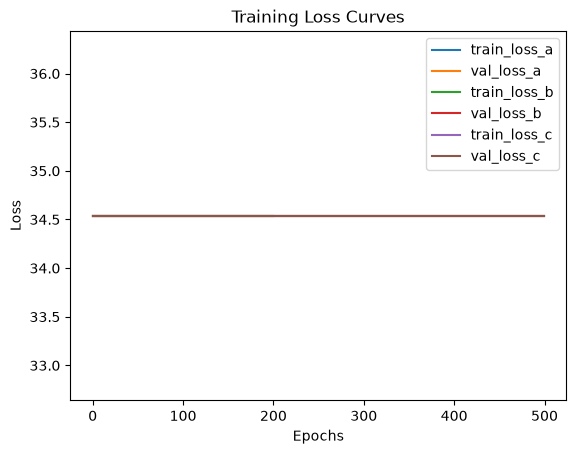

In [7]:
# afficher les courbes loss_a
import matplotlib.pyplot as plt
plt.plot(loss_a["train"], label="train_loss_a")
plt.plot(loss_a["val"], label="val_loss_a")
plt.plot(loss_b["train"], label="train_loss_b")
plt.plot(loss_b["val"], label="val_loss_b")
plt.plot(loss_c["train"], label="train_loss_c")
plt.plot(loss_c["val"], label="val_loss_c")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.show()

In [8]:
def afficher_matrice_confusion(lemodele, donnees_testees, titre):
    # eval() désactive le dropout, qui ne sert qu'à l'entraînement
    lemodele.eval()

    with th.no_grad():
        # Encodage des nœuds : en GAE, z est directement la sortie de l'encodeur
        z = lemodele.encode(donnees_testees.x, donnees_testees.edge_index)

        # Arêtes positives et négatives du split évalué
        pos_edges = donnees_testees.pos_edge_label_index
        neg_edges = donnees_testees.neg_edge_label_index
        edges = th.cat([pos_edges, neg_edges], dim=1)

        probabilites = lemodele.decode(z, edges, sigmoid=True)
        auc, ap = lemodele.test(z, pos_edges, neg_edges)        # tuple (auc, ap)
        predictions = (probabilites >= 0.5).long().cpu().numpy()

        vrais_labels = th.cat([
            th.ones(pos_edges.size(1), dtype=th.long),
            th.zeros(neg_edges.size(1), dtype=th.long),
        ]).numpy()

    matrice = confusion_matrix(vrais_labels, predictions, labels=[0, 1])
    print(f"\nMatrice de confusion : {titre}")
    print("Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]")
    print(matrice)
    print(f"Perf : AUC {auc:.3f} (vrais positifs / faux positifs) - AP {ap:.3f} (précision / rappel)")
    return auc, ap


afficher_matrice_confusion(model_a, train_data, "model_a train_data ")
afficher_matrice_confusion(model_a, test_data, "model_a test_data")

afficher_matrice_confusion(model_b, train_data, "model_b train_data ")
afficher_matrice_confusion(model_b, test_data, "model_b test_data")

afficher_matrice_confusion(model_c, train_data, "model_c train_data ")
afficher_matrice_confusion(model_c, test_data, "model_c test_data")
    


Matrice de confusion : model_a train_data 
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[   0 9484]
 [   0 9484]]
Perf : AUC 0.500 (vrais positifs / faux positifs) - AP 0.500 (précision / rappel)

Matrice de confusion : model_a test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[   0 2709]
 [   0 2709]]
Perf : AUC 0.500 (vrais positifs / faux positifs) - AP 0.500 (précision / rappel)

Matrice de confusion : model_b train_data 
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[   0 9484]
 [   0 9484]]
Perf : AUC 0.500 (vrais positifs / faux positifs) - AP 0.500 (précision / rappel)

Matrice de confusion : model_b test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[   0 2709]
 [   0 2709]]
Perf : AUC 0.500 (vrais positifs / faux positifs) - AP 0.500 (précision / rappel)

Matrice de confusion : model_c train_data 
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-ar

(0.5, 0.5)

In [9]:
z  =model_a.encode(test_data.x, test_data.edge_index)
#
probabilites = model_a.decode(z, test_data.pos_edge_label_index, sigmoid=True)

pos_edges = test_data.pos_edge_label_index
neg_edges = test_data.neg_edge_label_index
perf=model_a.test(z, pos_edges, neg_edges)  
print(perf)

(0.5, 0.5)


In [10]:
test_data.pos_edge_label_index

tensor([[ 663,  215,  857,  ...,   36,   25,  156],
        [1064,  464, 1321,  ...,   70,  253, 1478]])